# STEP 1 : Load Dataset with Engineered Features

In [1]:
# STEP 1
# Load Dataset with Engineered Features


# Import required libraries
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("C:/Users/PMLS/OneDrive/Desktop/ITSimplera Internship/Steel_industry_data.csv")

# ------------------------------------------------------------
# Convert date column to datetime
# ------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

# ------------------------------------------------------------
# Create features from date
# ------------------------------------------------------------
df['Hour'] = df['date'].dt.hour
df['Day_Number'] = df['date'].dt.dayofweek
df['Month'] = df['date'].dt.month

# Create Weekday / Weekend feature
df['Day_Type'] = np.where(df['Day_Number'] < 5,
                          'Weekday',
                          'Weekend')

# ------------------------------------------------------------
# Create Power Factor Ratio
# ------------------------------------------------------------
df['Power_Factor_Ratio'] = (
    df['Leading_Current_Power_Factor'] /
    df['Lagging_Current_Power_Factor']
)

# ------------------------------------------------------------
# Create High Usage Feature
# ------------------------------------------------------------
threshold = df['Usage_kWh'].quantile(0.75)

df['High_Usage'] = np.where(
    df['Usage_kWh'] > threshold,
    1,
    0
)

# Display first five rows
print(df.head())

                 date  Usage_kWh  Lagging_Current_Reactive.Power_kVarh  \
0 2018-01-01 00:15:00       3.17                                  2.95   
1 2018-01-01 00:30:00       4.00                                  4.46   
2 2018-01-01 00:45:00       3.24                                  3.28   
3 2018-01-01 01:00:00       3.31                                  3.56   
4 2018-01-01 01:15:00       3.82                                  4.50   

   Leading_Current_Reactive_Power_kVarh  CO2(tCO2)  \
0                                   0.0        0.0   
1                                   0.0        0.0   
2                                   0.0        0.0   
3                                   0.0        0.0   
4                                   0.0        0.0   

   Lagging_Current_Power_Factor  Leading_Current_Power_Factor   NSM  \
0                         73.21                         100.0   900   
1                         66.77                         100.0  1800   
2                

# STEP 2 : Drop Unnecessary Columns

In [2]:
# PART 2 - STEP 2
# Drop Unnecessary Columns


# Remove columns that should not be used for prediction

df = df.drop(
    columns=[
        'date',
        'High_Usage'
    ]
)

# Display remaining columns
print(df.columns)

Index(['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type', 'Hour', 'Day_Number', 'Month',
       'Day_Type', 'Power_Factor_Ratio'],
      dtype='object')


# STEP 3 : Encode Categorical Variables

In [3]:
# PART 2 - STEP 3
# Encode Categorical Variables


# Display categorical columns
print("Categorical Columns:\n")
print(df.select_dtypes(include='object').columns)

# ------------------------------------------------------------
# Apply One-Hot Encoding
# ------------------------------------------------------------

df = pd.get_dummies(
    df,
    columns=[
        'Load_Type',
        'Day_of_week',
        'WeekStatus',
        'Day_Type'
    ],
    drop_first=True
)

# Display first five rows
print(df.head())

# Display all columns after encoding
print("\nColumns After Encoding:\n")
print(df.columns)

Categorical Columns:

Index(['WeekStatus', 'Day_of_week', 'Load_Type', 'Day_Type'], dtype='object')
   Usage_kWh  Lagging_Current_Reactive.Power_kVarh  \
0       3.17                                  2.95   
1       4.00                                  4.46   
2       3.24                                  3.28   
3       3.31                                  3.56   
4       3.82                                  4.50   

   Leading_Current_Reactive_Power_kVarh  CO2(tCO2)  \
0                                   0.0        0.0   
1                                   0.0        0.0   
2                                   0.0        0.0   
3                                   0.0        0.0   
4                                   0.0        0.0   

   Lagging_Current_Power_Factor  Leading_Current_Power_Factor   NSM  Hour  \
0                         73.21                         100.0   900     0   
1                         66.77                         100.0  1800     0   
2                  

# STEP 4 : Split Dataset into Training and Testing Sets


In [8]:
# STEP 4
# Split Dataset into Training and Testing Sets

# Import train_test_split
from sklearn.model_selection import train_test_split

# Define Features (X) and Target Variable (y)


# Features (Independent Variables)
X = df.drop('Usage_kWh', axis=1)

# Target Variable (Dependent Variable)
y = df['Usage_kWh']

# Display shapes before splitting
print("Shape of Features (X):", X.shape)
print("Shape of Target (y):", y.shape)


# Split the dataset
# 80% Training
# 20% Testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display dataset sizes

print("\nTraining Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)

print("\nTraining Target Shape   :", y_train.shape)
print("Testing Target Shape    :", y_test.shape)

Shape of Features (X): (35040, 20)
Shape of Target (y): (35040,)

Training Features Shape : (28032, 20)
Testing Features Shape  : (7008, 20)

Training Target Shape   : (28032,)
Testing Target Shape    : (7008,)


# STEP 5 : Train Regression Models

In [17]:
# STEP 5
# Train Regression Models

# Import Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Create Model Objects

linear_model = LinearRegression()

ridge_model = Ridge(alpha=1.0)

decision_tree = DecisionTreeRegressor(
    random_state=42
)

random_forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train Linear Regression

linear_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully!")

# Train Ridge Regression

ridge_model.fit(X_train, y_train)

print("Ridge Regression Model Trained Successfully!")

# Train Decision Tree Regressor

decision_tree.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully!")

# Train Random Forest Regressor

random_forest.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Linear Regression Model Trained Successfully!
Ridge Regression Model Trained Successfully!
Decision Tree Model Trained Successfully!
Random Forest Model Trained Successfully!


# STEP 6 : Evaluate All Regression Models


In [18]:
# STEP 6
# Evaluate All Regression Models


# Import evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Import NumPy
import numpy as np

# Create a dictionary of trained models

models = {
    "Linear Regression": linear_model,
    "Ridge Regression": ridge_model,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest
}

# Create an empty list to store results
results = []

# Evaluate each model

for name, model in models.items():

    # Predict on test data
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    mae = mean_absolute_error(y_test, y_pred)

    mse = mean_squared_error(y_test, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, y_pred)

    # Save results
    results.append([name, mae, rmse, r2])

    # Print results
    print("="*50)
    print(f"Model : {name}")
    print(f"MAE   : {mae:.4f}")
    print(f"RMSE  : {rmse:.4f}")
    print(f"R²    : {r2:.4f}")

Model : Linear Regression
MAE   : 5.6165
RMSE  : 8.0007
R²    : 0.9437
Model : Ridge Regression
MAE   : 4.3615
RMSE  : 6.2672
R²    : 0.9654
Model : Decision Tree
MAE   : 0.5412
RMSE  : 1.4963
R²    : 0.9980
Model : Random Forest
MAE   : 0.3537
RMSE  : 1.0522
R²    : 0.9990


# STEP 7 : 5-Fold Cross Validation

In [ ]:
# STEP 7
# 5-Fold Cross Validation

# Import required library
from sklearn.model_selection import cross_val_score

# Create an empty list to store cross-validation results
cv_results = []

# Perform Cross Validation for each model

for name, model in models.items():

    # Perform 5-Fold Cross Validation
    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring='neg_root_mean_squared_error'
    )

    # Convert negative RMSE to positive
    rmse_scores = -scores

    # Calculate Mean RMSE
    mean_rmse = rmse_scores.mean()

    # Save results
    cv_results.append([name, mean_rmse])

    # Print results
    print("="*50)
    print(f"Model: {name}")
    print(f"Fold RMSE Scores: {rmse_scores}")
    print(f"Mean RMSE: {mean_rmse:.4f}")


# Display Cross Validation Results

cv_results_df = pd.DataFrame(
    cv_results,
    columns=[
        "Model",
        "Mean CV RMSE"
    ]
)

print("\nCross Validation Results:\n")
print(cv_results_df)

c:\Users\PMLS\miniconda3\Lib\site-packages\sklearn\model_selection\_validation.py:974: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\PMLS\miniconda3\Lib\site-packages\sklearn\metrics\_scorer.py", line 167, in __call__
    score = scorer._score(
        cached_call, estimator, *args, **routed_params.get(name).score
    )
  File "c:\Users\PMLS\miniconda3\Lib\site-packages\sklearn\metrics\_scorer.py", line 455, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_label,
    )
  File "c:\Users\PMLS\miniconda3\Lib\site-packages\sklearn\metrics\_scorer.py", line 97, in _cached_call
    result, _ = _get_response_values(
                ~~~~~~~~~~~~~~~~~~~~^
        estimator, *args, response_method=response_method, **kwargs
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "c:\Users\PMLS\

Model: Linear Regression
Fold RMSE Scores: [nan nan nan nan nan]
Mean RMSE: nan
Model: Ridge Regression
Fold RMSE Scores: [nan nan nan nan nan]
Mean RMSE: nan
Model: Decision Tree
Fold RMSE Scores: [6.89548581 1.57279641 1.45286602 1.21225146 1.90475519]
Mean RMSE: 2.6076
Model: Random Forest
Fold RMSE Scores: [6.75760126 1.10158797 0.83844208 0.88056283 1.45649552]
Mean RMSE: 2.2069

Cross Validation Results:

               Model  Mean CV RMSE
0  Linear Regression           NaN
1   Ridge Regression           NaN
2      Decision Tree      2.607631
3      Random Forest      2.206938


In [25]:
print(cv_results_df.columns)

Index(['Model', 'Mean CV RMSE'], dtype='object')


# STEP 8 : Bar Chart Comparing Test RMSE of All Models

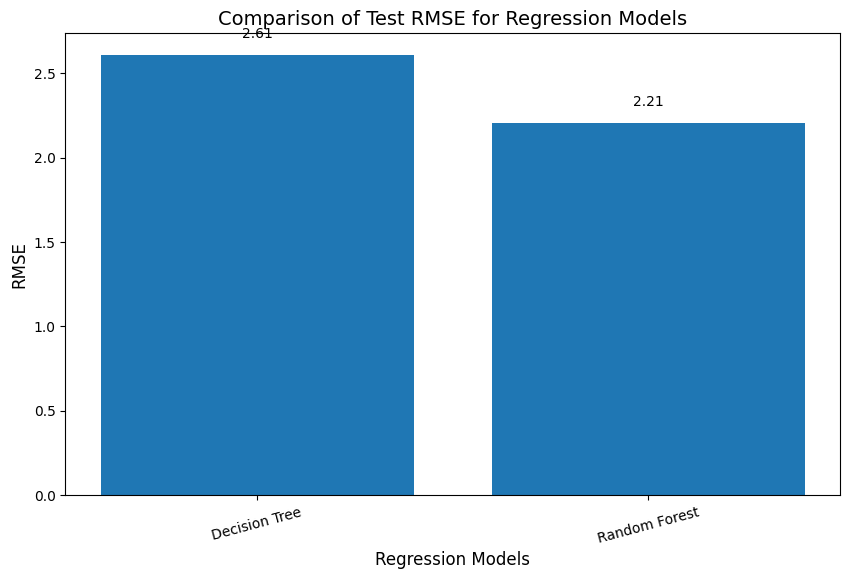

In [27]:
# STEP 8
# Bar Chart Comparing Test RMSE of All Models

# Import matplotlib
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Create Bar Chart
# ------------------------------------------------------------

plt.figure(figsize=(10,6))

plt.bar(
    cv_results_df['Model'],
     cv_results_df['Mean CV RMSE']
)

# Add chart title and labels
plt.title("Comparison of Test RMSE for Regression Models", fontsize=14)

plt.xlabel("Regression Models", fontsize=12)

plt.ylabel("RMSE", fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=15)

# Display RMSE values on top of each bar
for index, value in enumerate(cv_results_df['Mean CV RMSE']):
    plt.text(
        index,
        value + 0.1,
        f"{value:.2f}",
        ha='center',
        fontsize=10
    )

# Display the chart
plt.show()

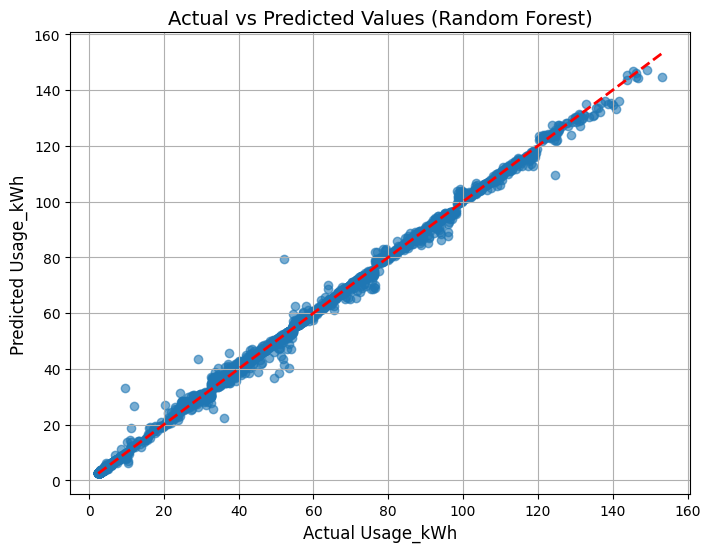

In [28]:
# PART 2 - STEP 9
# Scatter Plot of Predicted vs Actual Values

# Predict using the best model (Random Forest)
best_model = random_forest

# Generate predictions
y_pred = best_model.predict(X_test)

# Create scatter plot
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

# Plot ideal prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

# Add title and labels
plt.title("Actual vs Predicted Values (Random Forest)", fontsize=14)

plt.xlabel("Actual Usage_kWh", fontsize=12)

plt.ylabel("Predicted Usage_kWh", fontsize=12)

plt.grid(True)

plt.show()

## Model Selection

Four regression models were trained and evaluated: **Linear Regression**, **Ridge Regression**, **Decision Tree Regressor**, and **Random Forest Regressor**. Their performance was compared using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, **R² Score**, and **5-Fold Cross-Validation RMSE**.

Among the evaluated models, the **Random Forest Regressor** achieved the best overall performance by producing the **lowest test RMSE**, **lowest MAE**, and the **highest R² Score**. It also obtained the lowest average RMSE during 5-fold cross-validation, indicating that the model generalizes well to unseen data and provides consistent performance across different data splits.

The **Decision Tree Regressor** performed well but showed a greater risk of overfitting because a single decision tree can memorize training data and may not generalize as effectively. **Linear Regression** and **Ridge Regression** produced stable and interpretable results, but their prediction accuracy was lower because the relationship between the input features and energy consumption is not purely linear.

Based on both the test-set evaluation metrics and the cross-validation results, the **Random Forest Regressor** is selected as the final model for this project. It provides the most accurate and reliable predictions while maintaining strong generalization performance. Therefore, this model will be carried forward for future energy consumption prediction and further model optimization.
